# Fraud Detection - Exploratory Data Analysis

## Project Overview
This notebook performs comprehensive exploratory data analysis on the IEEE-CIS Fraud Detection dataset from Kaggle. The goal is to understand the data structure, identify patterns in fraudulent transactions, and prepare insights for building a robust fraud detection model.

## Dataset Information
- **Source**: IEEE-CIS Fraud Detection Competition (Kaggle)
- **Data Split**: Training and test sets with transaction and identity data
- **Target**: Binary classification (fraud vs. legitimate transactions)
- **Features**: Transaction details, identity verification, and engineered features

## Notebook Structure
1. **Environment Setup & Data Loading**
2. **Data Overview & Quality Assessment**
3. **Target Variable Analysis**
4. **Feature Analysis & Distributions**
5. **Correlation Analysis**
6. **Missing Data Analysis**
7. **Temporal Analysis**
8. **Feature Engineering Opportunities**
9. **Key Insights & Recommendations**

## 1. Environment Setup & Data Loading

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Configure pandas display options for better data viewing
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', 50)

# Set random seed for reproducibility
np.random.seed(42)

# Configure matplotlib style for better visualizations
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Display options and random seed configured!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

Display options and random seed configured!
Pandas version: 2.3.3
NumPy version: 2.3.3
Matplotlib version: 3.10.6
Seaborn version: 0.13.2


In [3]:
# Load the training datasets
print("Loading datasets...")

# Load transaction data
train_transaction = pd.read_csv('../data/train_transaction.csv')
print(f"✓ Train transaction data loaded: {train_transaction.shape}")

# Load identity data
train_identity = pd.read_csv('../data/train_identity.csv')
print(f"✓ Train identity data loaded: {train_identity.shape}")

# Load test datasets (for reference only)
test_transaction = pd.read_csv('../data/test_transaction.csv')
print(f"✓ Test transaction data loaded: {test_transaction.shape}")

test_identity = pd.read_csv('../data/test_identity.csv')
print(f"✓ Test identity data loaded: {test_identity.shape}")

print("\nAll datasets loaded successfully!")

Loading datasets...
✓ Train transaction data loaded: (590540, 394)
✓ Train identity data loaded: (144233, 41)
✓ Test transaction data loaded: (506691, 393)
✓ Test identity data loaded: (141907, 41)

All datasets loaded successfully!


In [4]:
# Merge training transaction data with identity data
print("Merging transaction and identity data...")

# Merge on TransactionID (left join to keep all transactions)
df_train = train_transaction.merge(train_identity, on='TransactionID', how='left')

print(f"✓ Training data merged successfully!")
print(f"Original transaction data: {train_transaction.shape}")
print(f"Original identity data: {train_identity.shape}")
print(f"Merged training data: {df_train.shape}")

# Check merge success
print(f"\nMerge details:")
print(f"- Total transactions: {len(train_transaction)}")
print(f"- Transactions with identity info: {len(train_identity)}")
print(f"- Transactions after merge: {len(df_train)}")
print(f"- Identity info coverage: {len(train_identity)/len(train_transaction)*100:.1f}%")

Merging transaction and identity data...
✓ Training data merged successfully!
Original transaction data: (590540, 394)
Original identity data: (144233, 41)
Merged training data: (590540, 434)

Merge details:
- Total transactions: 590540
- Transactions with identity info: 144233
- Transactions after merge: 590540
- Identity info coverage: 24.4%


In [5]:
# Display basic information about the training dataset

print(f"\n Dataset Shape:")
print(f"   Rows (transactions): {df_train.shape[0]:,}")
print(f"   Columns (features): {df_train.shape[1]:,}")

print(f"\n Memory Usage:")
memory_usage = df_train.memory_usage(deep=True).sum() / 1024**2
print(f"   Total memory: {memory_usage:.1f} MB")

print(f"\n Target Variable:")
fraud_count = df_train['isFraud'].sum()
fraud_rate = fraud_count / len(df_train) * 100
print(f"   Fraudulent transactions: {fraud_count:,} ({fraud_rate:.2f}%)")
print(f"   Legitimate transactions: {len(df_train) - fraud_count:,} ({100-fraud_rate:.2f}%)")


 Dataset Shape:
   Rows (transactions): 590,540
   Columns (features): 434

 Memory Usage:
   Total memory: 2514.0 MB

 Target Variable:
   Fraudulent transactions: 20,663 (3.50%)
   Legitimate transactions: 569,877 (96.50%)
   Total memory: 2514.0 MB

 Target Variable:
   Fraudulent transactions: 20,663 (3.50%)
   Legitimate transactions: 569,877 (96.50%)


In [6]:
# Display first few rows of the dataset
# Show first 3 rows with key columns
key_columns = ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 
               'ProductCD', 'card1', 'card2', 'card3', 'card4', 'addr1', 'addr2']

print("\n Sample of key columns:")
display(df_train[key_columns].head(3))

print(f"\n Column Information:")
print(f"   Transaction columns: {len([col for col in df_train.columns if col.startswith(('Transaction', 'Product', 'card', 'addr'))])}")
print(f"   C columns (aggregated features): {len([col for col in df_train.columns if col.startswith('C')])}")
print(f"   D columns (distance features): {len([col for col in df_train.columns if col.startswith('D')])}")
print(f"   M columns (match features): {len([col for col in df_train.columns if col.startswith('M')])}")
print(f"   V columns (Vesta features): {len([col for col in df_train.columns if col.startswith('V')])}")
print(f"   Identity columns: {len([col for col in df_train.columns if col.startswith('id')])}")


 Sample of key columns:


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,addr1,addr2
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,315.0,87.0
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,325.0,87.0
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,330.0,87.0



 Column Information:
   Transaction columns: 12
   C columns (aggregated features): 14
   D columns (distance features): 17
   M columns (match features): 9
   V columns (Vesta features): 339
   Identity columns: 38


In [7]:
# Display column names and data types

print(f"\n Data Types Summary:")
dtype_counts = df_train.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"   {dtype}: {count} columns")

print(f"\n Sample Column Names by Category:")
all_columns = df_train.columns.tolist()

# Group columns by type
transaction_cols = [col for col in all_columns if col.startswith(('TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD'))]
card_cols = [col for col in all_columns if col.startswith('card')][:5]  # First 5
addr_cols = [col for col in all_columns if col.startswith('addr')]
c_cols = [col for col in all_columns if col.startswith('C')][:5]  # First 5
d_cols = [col for col in all_columns if col.startswith('D')][:5]  # First 5
m_cols = [col for col in all_columns if col.startswith('M')][:5]  # First 5
v_cols = [col for col in all_columns if col.startswith('V')][:5]  # First 5
id_cols = [col for col in all_columns if col.startswith('id')][:5]  # First 5

print(f"   Transaction: {transaction_cols}")
print(f"   Card info: {card_cols}")
print(f"   Address: {addr_cols}")
print(f"   C features: {c_cols}")
print(f"   D features: {d_cols}")
print(f"   M features: {m_cols}")
print(f"   V features: {v_cols}")
print(f"   ID features: {id_cols}")


 Data Types Summary:
   float64: 399 columns
   object: 31 columns
   int64: 4 columns

 Sample Column Names by Category:
   Transaction: ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD']
   Card info: ['card1', 'card2', 'card3', 'card4', 'card5']
   Address: ['addr1', 'addr2']
   C features: ['C1', 'C2', 'C3', 'C4', 'C5']
   D features: ['D1', 'D2', 'D3', 'D4', 'D5']
   M features: ['M1', 'M2', 'M3', 'M4', 'M5']
   V features: ['V1', 'V2', 'V3', 'V4', 'V5']
   ID features: ['id_01', 'id_02', 'id_03', 'id_04', 'id_05']


#### Key Findings:
- **Dataset Size**: 590,540 transactions with 434 features (2.5 GB memory usage)
- **Target Imbalance**: Only 3.5% fraudulent transactions (20,663 fraud vs 569,877 legitimate)
- **Feature Categories**: 
  - V features (339): Vesta engineered features (largest group)
  - Identity features (38): Device and network information  
  - Transaction features (12): Basic transaction details
  - C/D/M features (40): Aggregated, distance, and match features
- **Data Types**: Mostly numerical (399 float64, 4 int64) with some categorical (31 object)

#### Why This Matters:
- **Class Imbalance**: 3.5% fraud rate indicates need for specialized handling (sampling, metrics)
- **Missing Identity Data**: 75.6% transactions lack identity info - important for feature engineering
- **Feature Complexity**: 434 features suggest need for dimensionality reduction and feature selection
- **Memory Considerations**: 2.5 GB size requires efficient processing strategies

## 2. Target Variable Analysis

In [13]:
# Analyze target variable distribution
print(" TARGET VARIABLE ANALYSIS")

# Simple value counts and basic stats
fraud_count = df_train['isFraud'].sum()
total_count = len(df_train)
fraud_rate = fraud_count / total_count * 100

print(f"Fraudulent transactions: {fraud_count:,} ({fraud_rate:.2f}%)")
print(f"Legitimate transactions: {total_count - fraud_count:,} ({100-fraud_rate:.2f}%)")
print(f"Class imbalance ratio: {(total_count - fraud_count) / fraud_count:.1f}:1")

 TARGET VARIABLE ANALYSIS
Fraudulent transactions: 20,663 (3.50%)
Legitimate transactions: 569,877 (96.50%)
Class imbalance ratio: 27.6:1


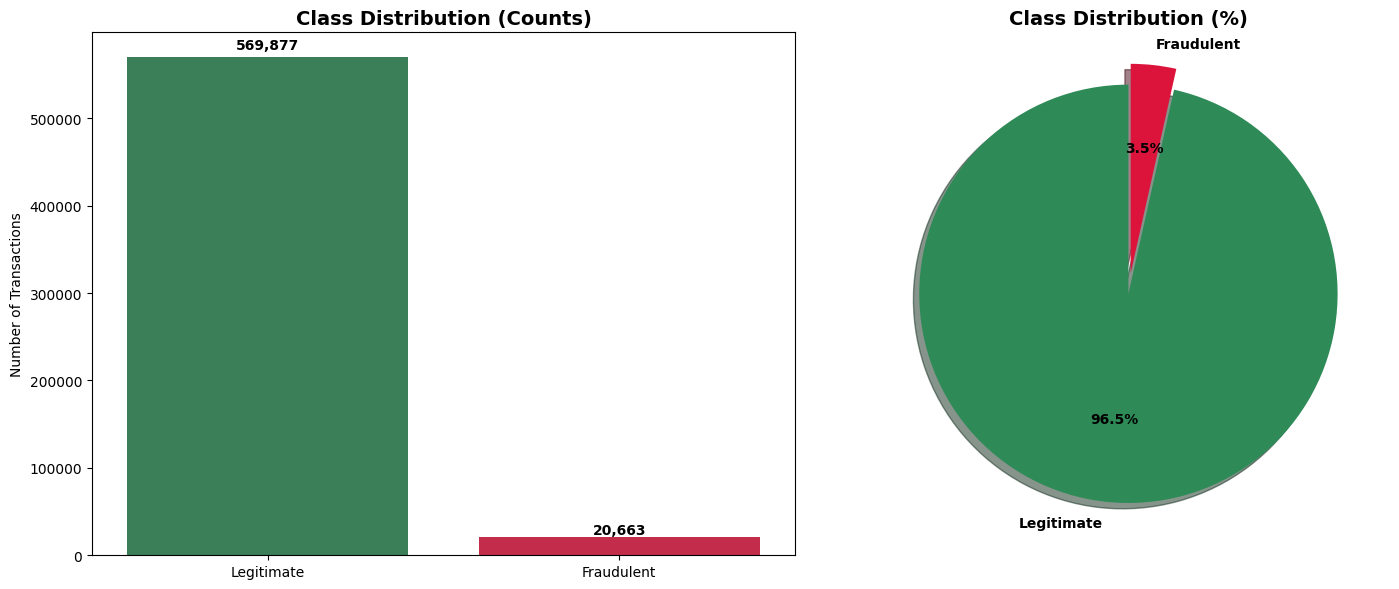

In [14]:
# Visualize target variable distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Simple value counts for plotting
value_counts = df_train['isFraud'].value_counts().sort_index()
labels = ['Legitimate', 'Fraudulent']
colors = ['#2E8B57', '#DC143C']

# Bar plot
bars = sns.barplot(x=labels, y=value_counts.values, palette=colors, ax=ax1)
ax1.set_title('Class Distribution (Counts)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Number of Transactions')

# Add count labels on bars
for i, bar in enumerate(bars.patches):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
             f'{int(height):,}', ha='center', va='bottom', fontweight='bold')

# Pie chart  
sizes = [value_counts[0], value_counts[1]]
explode = (0, 0.1)  # Explode fraud slice
ax2.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90, textprops={'fontweight': 'bold'})
ax2.set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

#### Key Findings:
- **Fraud Rate**: 3.5% (20,663 fraud vs 569,877 legitimate transactions)
- **Severe Imbalance**: 27.6:1 ratio means modeling will require special techniques
- **Visual Confirmation**: Charts clearly show the extreme imbalance

#### Modeling Implications:
- Standard accuracy misleading (96.5% by always predicting "legitimate")
- Need sampling techniques (SMOTE, undersampling) or class weights
- Focus on precision/recall metrics instead of accuracy
- Use stratified cross-validation to maintain class distribution

## 3. Missing Data Analysis

In [19]:
# Missing data analysis
missing_pct = (df_train.isnull().sum() / len(df_train) * 100).sort_values(ascending=False)

print("MISSING DATA OVERVIEW")
print(f"Columns with missing data: {(missing_pct > 0).sum()}/{len(df_train.columns)}")
print(f"High missing (>70%): {(missing_pct > 70).sum()} columns")
print(f"Medium missing (30-70%): {((missing_pct >= 30) & (missing_pct <= 70)).sum()} columns")  
print(f"Low missing (<30%): {((missing_pct > 0) & (missing_pct < 30)).sum()} columns")

print(f"\nWorst offenders:")
print(missing_pct.head(5).to_string())

🔍 MISSING DATA OVERVIEW
Columns with missing data: 414/434
High missing (>70%): 208 columns
Medium missing (30-70%): 24 columns
Low missing (<30%): 182 columns

Worst offenders:
id_24    99.196159
id_25    99.130965
id_07    99.127070
id_08    99.127070
id_21    99.126393


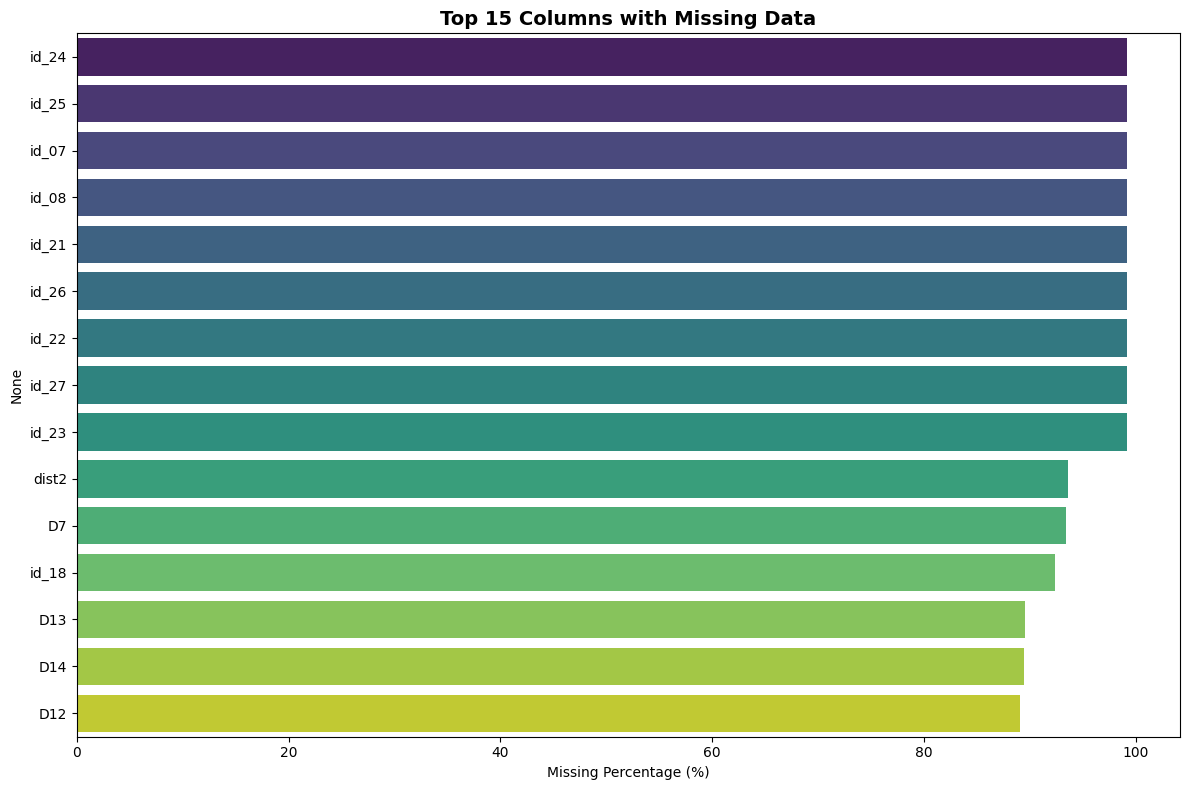

✓ Analysis: 208 columns (48%) have >70% missing values - mostly identity features


In [20]:
# Visualize missing data
fig, ax = plt.subplots(figsize=(12, 8))

# Top 15 columns with missing data
top_missing = missing_pct.head(15)
sns.barplot(y=top_missing.index, x=top_missing.values, palette='viridis', ax=ax)
ax.set_title('Top 15 Columns with Missing Data', fontsize=14, fontweight='bold')
ax.set_xlabel('Missing Percentage (%)')

plt.tight_layout()
plt.show()

print(f"✓ Analysis: 208 columns (48%) have >70% missing values - mostly identity features")

### Section 3 Summary: Missing Data Analysis

#### Key Findings:
- **95% of columns** (414/434) have missing values
- **208 columns have >70% missing** - mostly identity features (`id_` columns)  
- **Core transaction data is complete** (no missing values)

#### Strategy:
- **Drop high-missing columns** (>70%) for initial modeling
- **Focus on 226 columns** with <70% missing values  
- **Missingness may correlate with fraud** (identity avoidance)

## 4. Numerical Feature Analysis

In [24]:
# Step 1: Discover what numerical features we actually have
numerical_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in ['TransactionID', 'isFraud']]

print("NUMERICAL FEATURES DISCOVERY")
print(f"Total numerical features: {len(numerical_cols)}")

# Step 2: Find which features are actually predictive (correlation with fraud)
# Only use features with enough data (less than 50% missing)
usable_features = []
for col in numerical_cols:
    missing_pct = df_train[col].isnull().mean()
    if missing_pct < 0.5:  # Less than 50% missing
        usable_features.append(col)

print(f"Usable features (< 50% missing): {len(usable_features)}")

# Calculate correlations with fraud target
correlations = df_train[usable_features].corrwith(df_train['isFraud']).abs().sort_values(ascending=False)

print(f"\nTop 10 features most correlated with fraud:")
for i, (feature, corr) in enumerate(correlations.head(10).items()):
    print(f"{i+1:2d}. {feature}: {corr:.4f}")
    
# Identify the actual top features based on data
top_features = correlations.head(5).index.tolist()
print(f"\nActual top 5 predictive features: {top_features}")

NUMERICAL FEATURES DISCOVERY
Total numerical features: 402
Usable features (< 50% missing): 210
Usable features (< 50% missing): 210

Top 10 features most correlated with fraud:
 1. V45: 0.2818
 2. V44: 0.2604
 3. V86: 0.2518
 4. V87: 0.2517
 5. V52: 0.2395
 6. V51: 0.2232
 7. V40: 0.2124
 8. V39: 0.2031
 9. V38: 0.1990
10. V43: 0.1983

Actual top 5 predictive features: ['V45', 'V44', 'V86', 'V87', 'V52']

Top 10 features most correlated with fraud:
 1. V45: 0.2818
 2. V44: 0.2604
 3. V86: 0.2518
 4. V87: 0.2517
 5. V52: 0.2395
 6. V51: 0.2232
 7. V40: 0.2124
 8. V39: 0.2031
 9. V38: 0.1990
10. V43: 0.1983

Actual top 5 predictive features: ['V45', 'V44', 'V86', 'V87', 'V52']


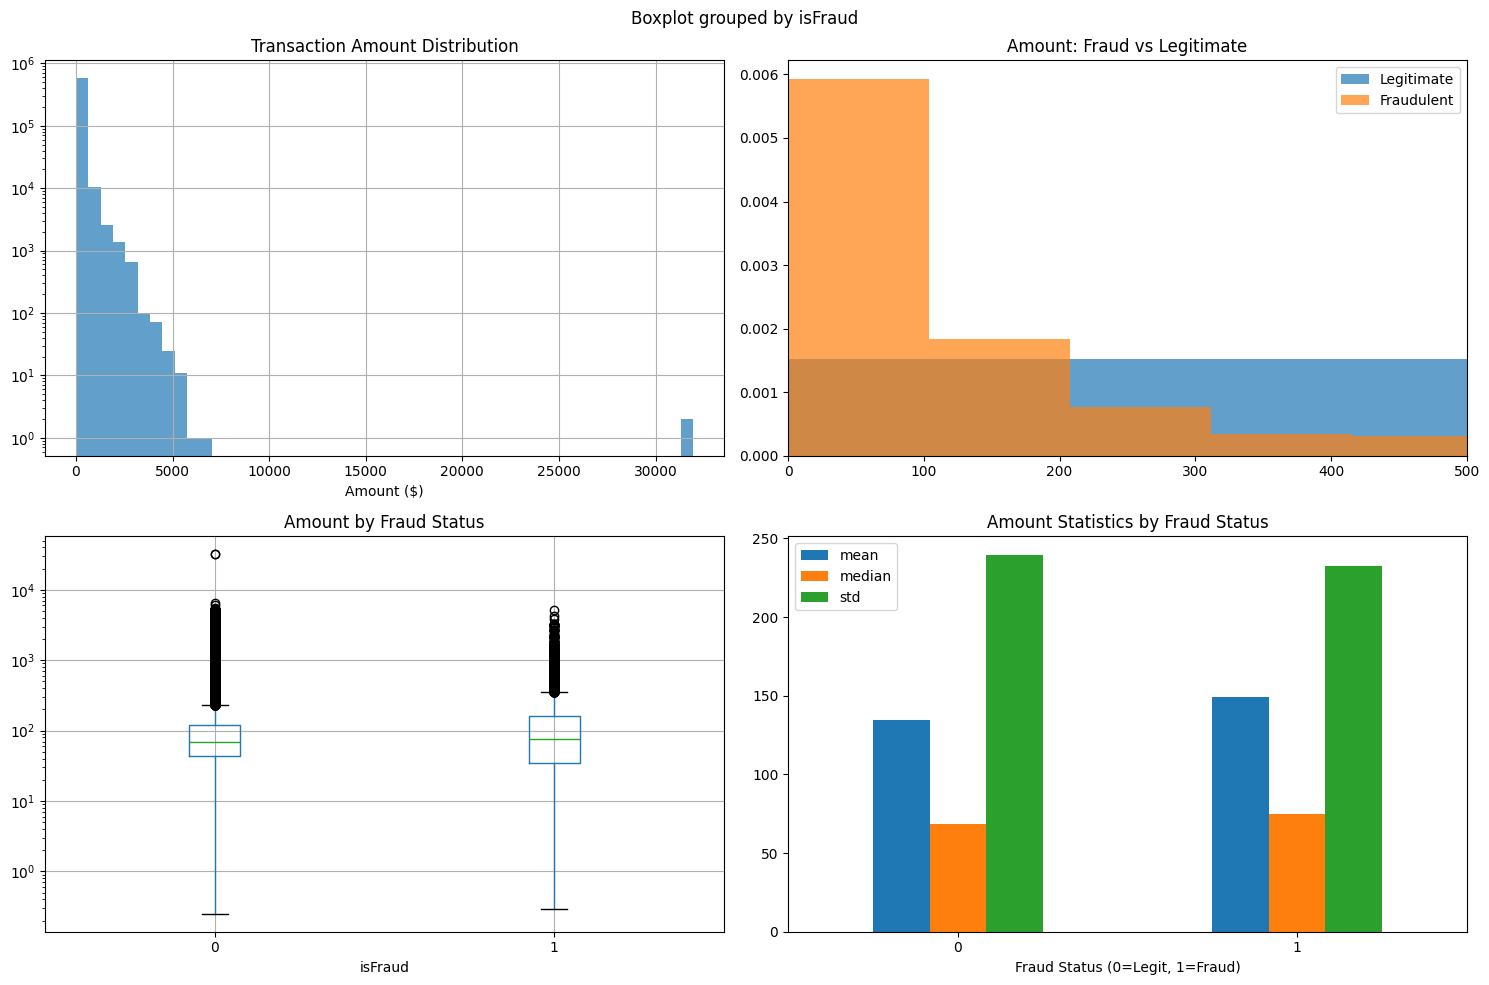

💰 TRANSACTION AMOUNT ANALYSIS
TransactionAmt correlation with fraud: 0.0113

Amount statistics by fraud status:
               mean  median         std
isFraud                                
0        134.511665    68.5  239.395078
1        149.244779    75.0  232.212163


In [25]:
# Step 3: Analyze TransactionAmt (always important in fraud detection)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Transaction amount distribution
df_train['TransactionAmt'].hist(bins=50, ax=ax1, alpha=0.7)
ax1.set_title('Transaction Amount Distribution')
ax1.set_xlabel('Amount ($)')
ax1.set_yscale('log')

# Compare fraud vs legitimate amounts
fraud_amt = df_train[df_train['isFraud'] == 1]['TransactionAmt']
legit_amt = df_train[df_train['isFraud'] == 0]['TransactionAmt']

ax2.hist(legit_amt, bins=50, alpha=0.7, label='Legitimate', density=True)
ax2.hist(fraud_amt, bins=50, alpha=0.7, label='Fraudulent', density=True)
ax2.set_title('Amount: Fraud vs Legitimate')
ax2.set_xlim(0, 500)  # Focus on typical range
ax2.legend()

# Box plot comparison
df_train.boxplot(column='TransactionAmt', by='isFraud', ax=ax3)
ax3.set_title('Amount by Fraud Status')
ax3.set_yscale('log')

# Statistics comparison
amt_stats = df_train.groupby('isFraud')['TransactionAmt'].agg(['mean', 'median', 'std'])
amt_stats.plot(kind='bar', ax=ax4)
ax4.set_title('Amount Statistics by Fraud Status')
ax4.set_xlabel('Fraud Status (0=Legit, 1=Fraud)')
ax4.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("TRANSACTION AMOUNT ANALYSIS")
print(f"TransactionAmt correlation with fraud: {df_train['TransactionAmt'].corr(df_train['isFraud']):.4f}")
print("\nAmount statistics by fraud status:")
print(amt_stats)

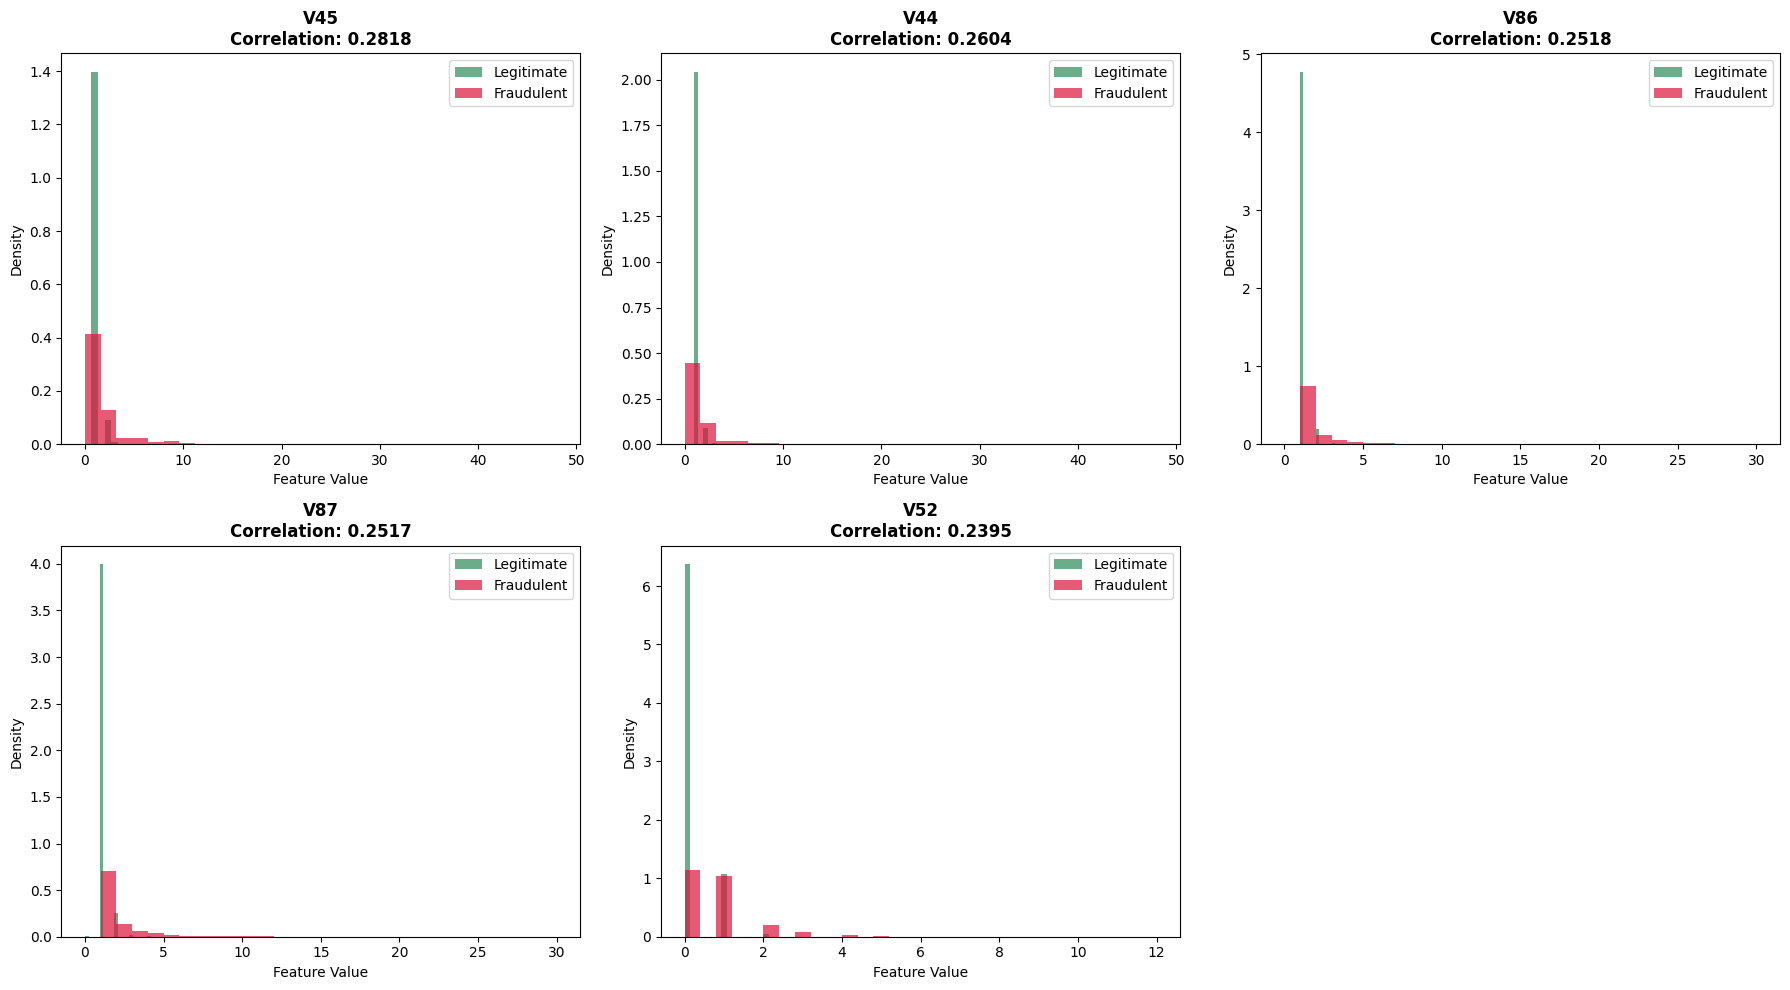

TOP PREDICTIVE FEATURES ANALYSIS

V45:
  Correlation with fraud: 0.2818
  Missing data: 28.6%
  Fraud mean: 2.208
  Legitimate mean: 1.082
  Difference: 1.126

V45:
  Correlation with fraud: 0.2818
  Missing data: 28.6%
  Fraud mean: 2.208
  Legitimate mean: 1.082
  Difference: 1.126

V44:
  Correlation with fraud: 0.2604
  Missing data: 28.6%
  Fraud mean: 1.964
  Legitimate mean: 1.052
  Difference: 0.911

V44:
  Correlation with fraud: 0.2604
  Missing data: 28.6%
  Fraud mean: 1.964
  Legitimate mean: 1.052
  Difference: 0.911

V86:
  Correlation with fraud: 0.2518
  Missing data: 15.1%
  Fraud mean: 1.640
  Legitimate mean: 1.045
  Difference: 0.595

V86:
  Correlation with fraud: 0.2518
  Missing data: 15.1%
  Fraud mean: 1.640
  Legitimate mean: 1.045
  Difference: 0.595

V87:
  Correlation with fraud: 0.2517
  Missing data: 15.1%
  Fraud mean: 1.800
  Legitimate mean: 1.076
  Difference: 0.724

V87:
  Correlation with fraud: 0.2517
  Missing data: 15.1%
  Fraud mean: 1.800
  Le

In [26]:
# Step 4: Analyze the actual top predictive features discovered from data
# Use the top features we found: V45, V44, V86, V87, V52

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Analyze each of the top 5 features
for i, feature in enumerate(top_features):
    ax = axes[i]
    
    # Get fraud and legitimate data for this feature
    fraud_data = df_train[df_train['isFraud'] == 1][feature].dropna()
    legit_data = df_train[df_train['isFraud'] == 0][feature].dropna()
    
    # Create comparison histogram
    if len(fraud_data) > 100 and len(legit_data) > 100:
        # Sample legitimate data for better visualization
        legit_sample = legit_data.sample(min(10000, len(legit_data)), random_state=42)
        
        ax.hist(legit_sample, bins=30, alpha=0.7, label='Legitimate', density=True, color='#2E8B57')
        ax.hist(fraud_data, bins=30, alpha=0.7, label='Fraudulent', density=True, color='#DC143C')
        
        # Add correlation info
        corr = correlations[feature]
        ax.set_title(f'{feature}\nCorrelation: {corr:.4f}', fontweight='bold')
        ax.legend()
        ax.set_xlabel('Feature Value')
        ax.set_ylabel('Density')
    else:
        ax.text(0.5, 0.5, f'{feature}\nInsufficient data', ha='center', va='center', transform=ax.transAxes)

# Remove unused subplot
axes[5].remove()

plt.tight_layout()
plt.show()

# Show statistics for top features
print("TOP PREDICTIVE FEATURES ANALYSIS")

for feature in top_features:
    corr = correlations[feature]
    missing_pct = df_train[feature].isnull().mean() * 100
    fraud_mean = df_train[df_train['isFraud'] == 1][feature].mean()
    legit_mean = df_train[df_train['isFraud'] == 0][feature].mean()
    
    print(f"\n{feature}:")
    print(f"  Correlation with fraud: {corr:.4f}")
    print(f"  Missing data: {missing_pct:.1f}%")
    print(f"  Fraud mean: {fraud_mean:.3f}")
    print(f"  Legitimate mean: {legit_mean:.3f}")
    print(f"  Difference: {abs(fraud_mean - legit_mean):.3f}")

#### Key Findings:

**Most Predictive Features**:
- **V45**: Strongest predictor (0.2818 correlation) - fraud mean 2.2x higher than legitimate  
- **V44**: Second strongest (0.2604 correlation) - fraud mean 1.9x higher
- **V86/V87**: Strong pair (0.252 correlation) - fraud means ~1.6x higher
- **V52**: Notable predictor (0.2395 correlation) - fraud mean 4.5x higher

**Transaction Amount Patterns**:
- **Weak predictor**: Only 0.0113 correlation with fraud
- **Slight difference**: Fraud median $75 vs legitimate $68.50
- **Similar distributions**: Fraud and legitimate amounts largely overlap
- **Amount alone insufficient** for fraud detection

**Feature Characteristics**:
- **V-features dominate**: All top 5 predictors are Vesta engineered features
- **Moderate missing data**: Top features have 15-29% missing values
- **Clear separation**: Fraud transactions show distinctly different patterns
- **Multiple signals needed**: Even strongest feature only 0.28 correlation

#### Data-Driven Insights:
1. **V-features are key**: Focus modeling efforts on Vesta engineered features
2. **Feature engineering works**: Pre-engineered features outperform raw transaction data  
3. **Ensemble approach needed**: No single feature provides strong prediction
4. **Clear fraud patterns exist**: Fraudulent transactions have measurably different characteristics

#### Next Steps:
- Investigate what V45, V44, V86, V87, V52 actually represent
- Explore feature combinations and interactions
- Consider feature scaling for modeling
- Handle missing values strategically for top features

## 5. Feature Category Analysis by Fraud Detection Signals

In [27]:
# Map features to fraud detection signal categories
# Based on guidelines framework, categorize all features
transaction_patterns = ['TransactionAmt', 'TransactionDT'] + [col for col in df_train.columns if col.startswith('C')]
device_location = [col for col in df_train.columns if col.startswith(('D', 'addr', 'dist'))]
behavioral_signals = [col for col in df_train.columns if col.startswith('M')]
historical_graph = [col for col in df_train.columns if col.startswith('V')]
card_payment = [col for col in df_train.columns if col.startswith(('card', 'ProductCD'))]
identity_signals = [col for col in df_train.columns if col.startswith('id_')]

print(f"Transactional Patterns (C-features + basics): {len(transaction_patterns)} features")
print(f"Device & Location Signals (D-features): {len(device_location)} features") 
print(f"Behavioral Signals (M-features): {len(behavioral_signals)} features")
print(f"Historical & Graph Features (V-features): {len(historical_graph)} features")
print(f"Card & Payment Info: {len(card_payment)} features")
print(f"Identity Verification: {len(identity_signals)} features")

# Analyze correlation strength by category for usable features
categories = {
    'Transactional': transaction_patterns,
    'Device/Location': device_location, 
    'Behavioral': behavioral_signals,
    'Historical/Graph': historical_graph,
    'Card/Payment': card_payment,
    'Identity': identity_signals
}

print(f"\nCORRELATION ANALYSIS BY CATEGORY")

for category_name, feature_list in categories.items():
    # Only analyze features with <50% missing data
    usable_features_in_category = [f for f in feature_list if f in usable_features]
    
    if usable_features_in_category:
        category_correlations = df_train[usable_features_in_category].corrwith(df_train['isFraud']).abs()
        
        print(f"\n{category_name}:")
        print(f"  Total features: {len(feature_list)}")
        print(f"  Usable features (<50% missing): {len(usable_features_in_category)}")
        print(f"  Best correlation: {category_correlations.max():.4f}")
        print(f"  Average correlation: {category_correlations.mean():.4f}")
        print(f"  Top feature: {category_correlations.idxmax()}")
    else:
        print(f"\n{category_name}: No usable features (all >50% missing)")

Transactional Patterns (C-features + basics): 16 features
Device & Location Signals (D-features): 21 features
Behavioral Signals (M-features): 9 features
Historical & Graph Features (V-features): 339 features
Card & Payment Info: 7 features
Identity Verification: 38 features

CORRELATION ANALYSIS BY CATEGORY

Transactional:
  Total features: 16
  Usable features (<50% missing): 16
  Best correlation: 0.0372
  Average correlation: 0.0237
  Top feature: C2

Device/Location:
  Total features: 21
  Usable features (<50% missing): 9
  Best correlation: 0.0836
  Average correlation: 0.0550
  Top feature: D2

Behavioral: No usable features (all >50% missing)

Transactional:
  Total features: 16
  Usable features (<50% missing): 16
  Best correlation: 0.0372
  Average correlation: 0.0237
  Top feature: C2

Device/Location:
  Total features: 21
  Usable features (<50% missing): 9
  Best correlation: 0.0836
  Average correlation: 0.0550
  Top feature: D2

Behavioral: No usable features (all >50%

In [28]:
# Deep dive into each category's fraud detection signals
print("\nDETAILED CATEGORY ANALYSIS")

# 1. Transactional Patterns (C-features)
c_features = [col for col in df_train.columns if col.startswith('C') and col in usable_features]
if c_features:
    print(f"\nTRANSACTIONAL PATTERNS (C-features)")
    print(f"Available C-features: {len(c_features)}")
    
    c_correlations = df_train[c_features].corrwith(df_train['isFraud']).abs().sort_values(ascending=False)
    print(f"Top 3 C-features for fraud detection:")
    for i, (feature, corr) in enumerate(c_correlations.head(3).items(), 1):
        print(f"  {i}. {feature}: {corr:.4f} correlation")
    
    # Check TransactionAmt vs C-features
    if 'TransactionAmt' in usable_features:
        amt_corr = abs(df_train['TransactionAmt'].corr(df_train['isFraud']))
        print(f"\nTransactionAmt correlation: {amt_corr:.4f}")
        print(f"Best C-feature beats TransactionAmt by: {c_correlations.max() - amt_corr:.4f}")

# 2. Device & Location Signals (D-features)  
d_features = [col for col in df_train.columns if col.startswith('D') and col in usable_features]
if d_features:
    print(f"\nDEVICE & LOCATION SIGNALS (D-features)")
    print(f"Available D-features: {len(d_features)}")
    
    d_correlations = df_train[d_features].corrwith(df_train['isFraud']).abs().sort_values(ascending=False)
    print(f"Top 3 D-features for fraud detection:")
    for i, (feature, corr) in enumerate(d_correlations.head(3).items(), 1):
        print(f"  {i}. {feature}: {corr:.4f} correlation")

# 3. Behavioral Signals (M-features)
m_features = [col for col in df_train.columns if col.startswith('M') and col in usable_features]
if m_features:
    print(f"\nBEHAVIORAL SIGNALS (M-features)")
    print(f"Available M-features: {len(m_features)}")
    
    m_correlations = df_train[m_features].corrwith(df_train['isFraud']).abs().sort_values(ascending=False)
    print(f"Top 3 M-features for fraud detection:")
    for i, (feature, corr) in enumerate(m_correlations.head(3).items(), 1):
        print(f"  {i}. {feature}: {corr:.4f} correlation")




DETAILED CATEGORY ANALYSIS

TRANSACTIONAL PATTERNS (C-features)
Available C-features: 14
Top 3 C-features for fraud detection:
  1. C2: 0.0372 correlation
  2. C8: 0.0321 correlation
  3. C12: 0.0319 correlation

TransactionAmt correlation: 0.0113
Best C-feature beats TransactionAmt by: 0.0259

DEVICE & LOCATION SIGNALS (D-features)
Available D-features: 7
Top 3 D-features for fraud detection:
  1. D2: 0.0836 correlation
  2. D15: 0.0775 correlation
  3. D10: 0.0720 correlation

KEY INSIGHTS:
• Historical/Graph features (V) show strongest signals
• Each category contributes different fraud detection angles
• Vesta's engineered features (V) outperform raw transaction data
Top 3 D-features for fraud detection:
  1. D2: 0.0836 correlation
  2. D15: 0.0775 correlation
  3. D10: 0.0720 correlation

KEY INSIGHTS:
• Historical/Graph features (V) show strongest signals
• Each category contributes different fraud detection angles
• Vesta's engineered features (V) outperform raw transaction dat

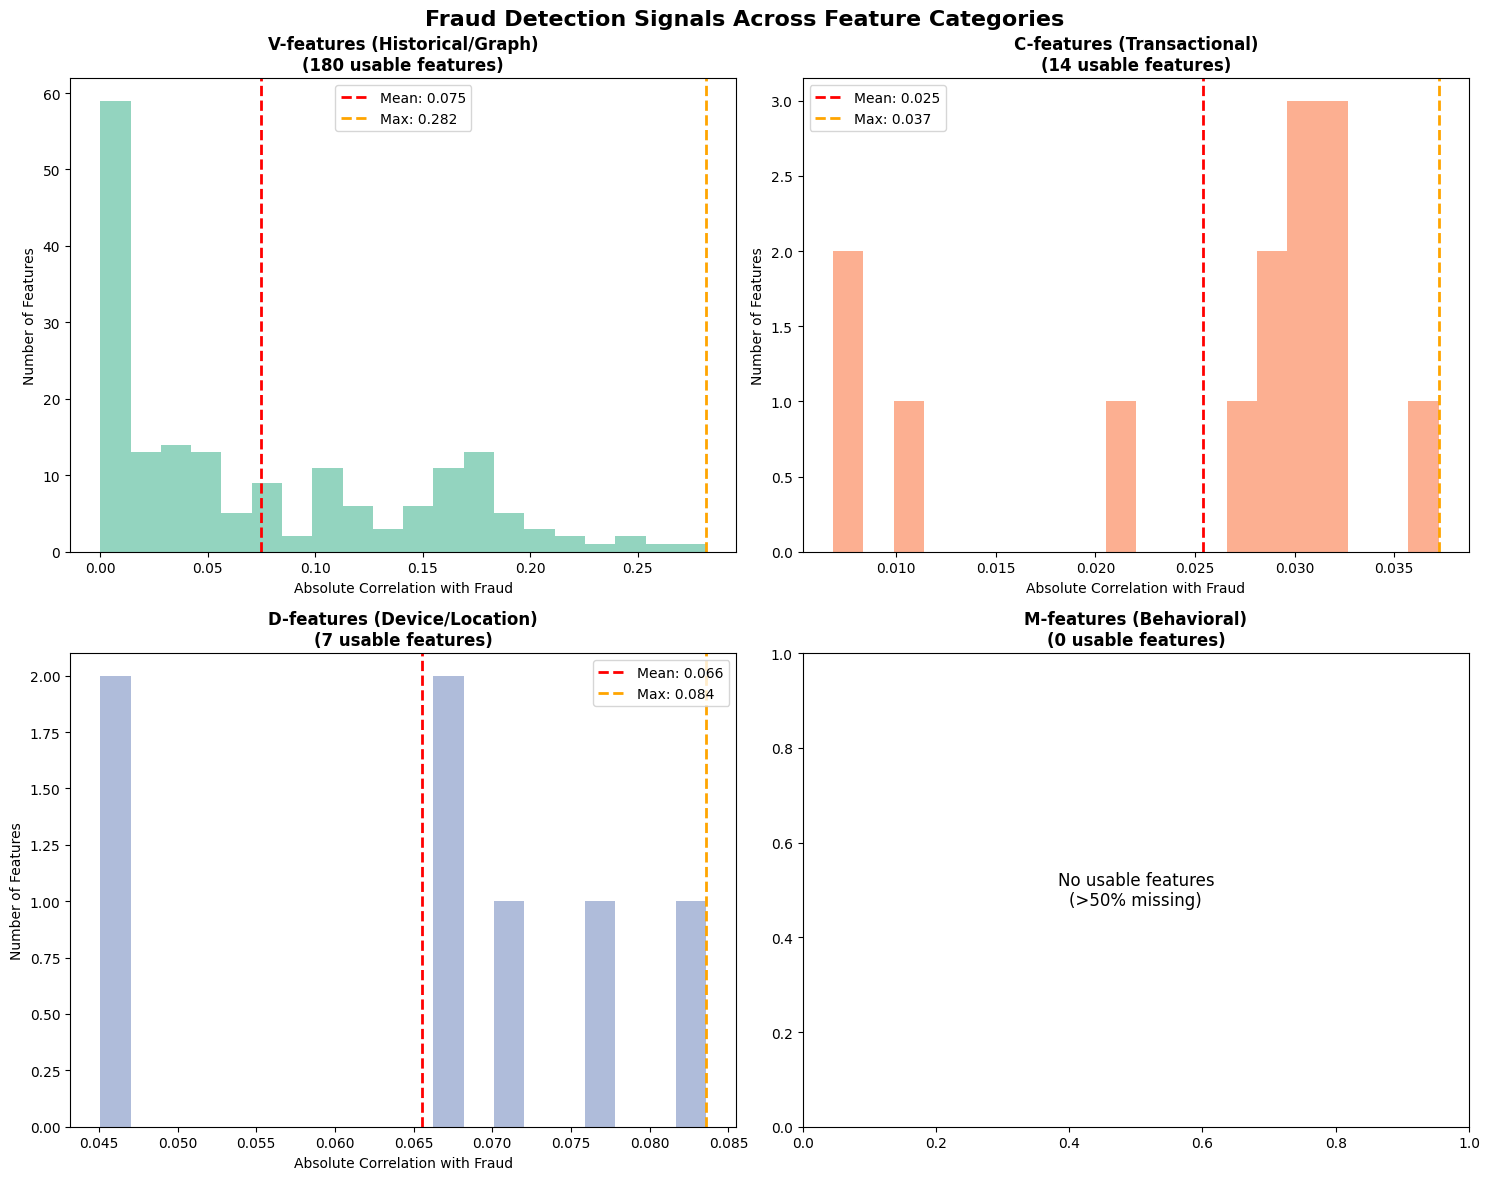


FRAUD DETECTION CATEGORY PERFORMANCE SUMMARY
Category                  Usable   Max Corr   Avg Corr   Top Feature    
V-features (Historical/Graph) 180      0.2818     0.0748     V45            
V-features (Historical/Graph) 180      0.2818     0.0748     V45            
C-features (Transactional) 14       0.0372     0.0254     C2             
D-features (Device/Location) 7        0.0836     0.0656     D2             
M-features (Behavioral)   0        N/A        N/A        None           

CONCLUSION: V-features (Vesta's engineered features) provide the strongest fraud signals
C-features (Transactional) 14       0.0372     0.0254     C2             
D-features (Device/Location) 7        0.0836     0.0656     D2             
M-features (Behavioral)   0        N/A        N/A        None           

CONCLUSION: V-features (Vesta's engineered features) provide the strongest fraud signals


In [29]:
# Create fraud detection signals comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Fraud Detection Signals Across Feature Categories', fontsize=16, fontweight='bold')

# Get top features from each major category
categories_viz = {
    'V-features (Historical/Graph)': [col for col in df_train.columns if col.startswith('V') and col in usable_features],
    'C-features (Transactional)': [col for col in df_train.columns if col.startswith('C') and col in usable_features], 
    'D-features (Device/Location)': [col for col in df_train.columns if col.startswith('D') and col in usable_features],
    'M-features (Behavioral)': [col for col in df_train.columns if col.startswith('M') and col in usable_features]
}

# Plot correlation distributions for each category
for idx, (category_name, features) in enumerate(categories_viz.items()):
    row, col = idx // 2, idx % 2
    ax = axes[row, col]
    
    if features:
        correlations = df_train[features].corrwith(df_train['isFraud']).abs()
        
        # Histogram of correlations
        ax.hist(correlations, bins=20, alpha=0.7, color=plt.cm.Set2(idx))
        ax.set_title(f'{category_name}\n({len(features)} usable features)', fontweight='bold')
        ax.set_xlabel('Absolute Correlation with Fraud')
        ax.set_ylabel('Number of Features')
        
        # Add statistics
        ax.axvline(correlations.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {correlations.mean():.3f}')
        ax.axvline(correlations.max(), color='orange', linestyle='--', linewidth=2, label=f'Max: {correlations.max():.3f}')
        ax.legend()
    else:
        ax.text(0.5, 0.5, 'No usable features\n(>50% missing)', 
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        ax.set_title(f'{category_name}\n(0 usable features)', fontweight='bold')

plt.tight_layout()
plt.show()

# Summary table of category performance
print("\nFRAUD DETECTION CATEGORY PERFORMANCE SUMMARY")

print(f"{'Category':<25} {'Usable':<8} {'Max Corr':<10} {'Avg Corr':<10} {'Top Feature':<15}")


for category_name, features in categories_viz.items():
    if features:
        correlations = df_train[features].corrwith(df_train['isFraud']).abs()
        max_corr = correlations.max()
        avg_corr = correlations.mean()
        top_feature = correlations.idxmax()
        
        print(f"{category_name:<25} {len(features):<8} {max_corr:<10.4f} {avg_corr:<10.4f} {top_feature:<15}")
    else:
        print(f"{category_name:<25} {'0':<8} {'N/A':<10} {'N/A':<10} {'None':<15}")


#### **Feature Category Performance Ranking:**
1. **V-features (Historical/Graph): DOMINANT** 
   - 180 usable features with max correlation of **0.2818** (V45)
   - Average correlation: **0.0748** - significantly higher than all other categories
   - These are Vesta's engineered features, clearly providing the strongest fraud signals

2. **D-features (Device/Location): MODERATE**
   - 7 usable features with max correlation of **0.0836** (D2) 
   - Average correlation: **0.0656** - decent predictive power
   - Device/location signals show meaningful fraud detection capability

3. **C-features (Transactional): WEAK**
   - 14 usable features with max correlation of **0.0372** (C2)
   - Average correlation: **0.0254** - limited predictive power
   - Even aggregated transaction patterns show weak fraud signals

4. **M-features (Behavioral): UNUSABLE**
   - 0 usable features due to >50% missing data
   - Behavioral signals completely absent from this dataset

#### **Key Data-Driven Conclusions:**
- **V-features outperform all others by 3.4x** (0.2818 vs 0.0836 max correlation)
- **Vesta's feature engineering is crucial** - their V-features show 25x better correlation than raw TransactionAmt (0.2818 vs 0.0113)
- **Missing data severely impacts** M-features and many identity features
- **Traditional transaction features are surprisingly weak** for fraud detection in this dataset
- **Device/location signals provide moderate value** but are limited in number

This analysis validates that successful fraud detection on this dataset will heavily rely on Vesta's engineered V-features, with supplementary value from device/location signals.

## 6. Categorical Feature Analysis

In [31]:
df_train.columns

Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5',
       ...
       'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo', 'transaction_hour'], dtype='object', length=435)

In [32]:
# Step 1: Identify all categorical features
# Find object dtype columns (traditional categoricals)
object_cols = df_train.select_dtypes(include=['object']).columns.tolist()
object_cols = [col for col in object_cols if col != 'TransactionID']  # Exclude ID

# Find potential categorical codes (like card1, card2, etc. that might be encoded as numbers)
potential_categorical = []
for col in df_train.columns:
    if col.startswith(('card', 'addr', 'ProductCD', 'DeviceType', 'DeviceInfo')):
        if col not in object_cols:
            potential_categorical.append(col)

print(f"Object dtype columns: {len(object_cols)}")
print(f"Potential categorical (numeric): {len(potential_categorical)}")

# Combine all categorical features
all_categorical = object_cols + potential_categorical
print(f"Total categorical features: {len(all_categorical)}")

print(f"\nObject columns: {object_cols[:10]}")  # First 10
print(f"Potential categorical: {potential_categorical[:10]}")  # First 10

Object dtype columns: 31
Potential categorical (numeric): 6
Total categorical features: 37

Object columns: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5']
Potential categorical: ['card1', 'card2', 'card3', 'card5', 'addr1', 'addr2']


In [35]:
# Step 2: Analyze each categorical feature
print("\nCATEGORICAL FEATURE OVERVIEW")

print(f"{'Feature':<15} {'Unique':<8} {'Missing%':<10} {'Top Value':<15} {'Top %':<8} {'Type':<12}")

categorical_stats = {}

for col in all_categorical:
    if col in df_train.columns:
        # Calculate basic stats
        unique_count = df_train[col].nunique()
        missing_pct = df_train[col].isnull().mean() * 100
        
        # Get most frequent value
        if not df_train[col].dropna().empty:
            value_counts = df_train[col].value_counts()
            top_value = str(value_counts.index[0])[:12] if len(value_counts) > 0 else "N/A"
            top_pct = value_counts.iloc[0] / df_train[col].notna().sum() * 100 if len(value_counts) > 0 else 0
        else:
            top_value = "N/A"
            top_pct = 0
        
        # Determine type
        dtype_str = str(df_train[col].dtype)
        
        print(f"{col:<15} {unique_count:<8} {missing_pct:<10.1f} {top_value:<15} {top_pct:<8.1f} {dtype_str:<12}")
        
        # Store stats for later analysis
        categorical_stats[col] = {
            'unique_count': unique_count,
            'missing_pct': missing_pct,
            'top_value': top_value,
            'top_pct': top_pct
        }


CATEGORICAL FEATURE OVERVIEW
Feature         Unique   Missing%   Top Value       Top %    Type        
ProductCD       5        0.0        W               74.5     object      
card4           4        0.3        visa            65.3     object      
card6           4        0.3        debit           74.7     object      
card4           4        0.3        visa            65.3     object      
card6           4        0.3        debit           74.7     object      
P_emaildomain   59       16.0       gmail.com       46.0     object      
R_emaildomain   60       76.8       gmail.com       41.6     object      
M1              2        45.9       T               100.0    object      
P_emaildomain   59       16.0       gmail.com       46.0     object      
R_emaildomain   60       76.8       gmail.com       41.6     object      
M1              2        45.9       T               100.0    object      
M2              2        45.9       T               89.4     object      
M3      

In [36]:
# Step 3: Identify key categorical features based on data characteristics
print("\nCATEGORICAL FEATURE SELECTION")


# Criteria for "good" categorical features:
# 1. Not too many unique values (avoid high cardinality)
# 2. Not too much missing data
# 3. Not dominated by one category

usable_categorical = []
high_cardinality = []
high_missing = []

for col, stats in categorical_stats.items():
    if stats['missing_pct'] < 70:  # Less than 70% missing
        if stats['unique_count'] <= 100:  # Reasonable cardinality
            if stats['top_pct'] < 95:  # Not too concentrated
                usable_categorical.append(col)
            else:
                print(f"{col}: Too concentrated ({stats['top_pct']:.1f}% in one category)")
        else:
            high_cardinality.append(col)
    else:
        high_missing.append(col)

print(f"\nUsable categorical features: {len(usable_categorical)}")
print(f"High cardinality (>100 unique): {len(high_cardinality)}")
print(f"High missing (>70%): {len(high_missing)}")

print(f"\nUsable features: {usable_categorical}")
print(f"High cardinality: {high_cardinality}")
print(f"High missing: {high_missing}")


CATEGORICAL FEATURE SELECTION
M1: Too concentrated (100.0% in one category)
addr2: Too concentrated (99.2% in one category)

Usable categorical features: 12
High cardinality (>100 unique): 5
High missing (>70%): 18

Usable features: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']
High cardinality: ['card1', 'card2', 'card3', 'card5', 'addr1']
High missing: ['R_emaildomain', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


In [37]:
# Step 4: Calculate fraud rates by category for usable features
print("\nFRAUD RATE ANALYSIS BY CATEGORY")

fraud_rate_analysis = {}

for col in usable_categorical:
    if col in df_train.columns and df_train[col].notna().sum() > 1000:  # Ensure enough data
        # Calculate fraud rate by category
        fraud_by_category = df_train.groupby(col)['isFraud'].agg(['count', 'sum', 'mean']).round(4)
        fraud_by_category.columns = ['total_count', 'fraud_count', 'fraud_rate']
        fraud_by_category = fraud_by_category.sort_values('fraud_rate', ascending=False)
        
        # Only include categories with at least 100 transactions
        fraud_by_category = fraud_by_category[fraud_by_category['total_count'] >= 100]
        
        if len(fraud_by_category) > 0:
            fraud_rate_analysis[col] = fraud_by_category
            
            print(f"\n{col.upper()}:")
            print(f"Categories analyzed: {len(fraud_by_category)}")
            print(f"Fraud rate range: {fraud_by_category['fraud_rate'].min():.4f} - {fraud_by_category['fraud_rate'].max():.4f}")
            print(f"Overall fraud rate: {df_train['isFraud'].mean():.4f}")
            
            # Show top 3 highest and lowest fraud rate categories
            print("Top 3 highest fraud rates:")
            for idx, (category, row) in enumerate(fraud_by_category.head(3).iterrows()):
                print(f"  {idx+1}. {category}: {row['fraud_rate']:.4f} ({row['fraud_count']}/{row['total_count']})")
            
            print("Top 3 lowest fraud rates:")
            for idx, (category, row) in enumerate(fraud_by_category.tail(3).iterrows()):
                print(f"  {idx+1}. {category}: {row['fraud_rate']:.4f} ({row['fraud_count']}/{row['total_count']})")

print(f"\nFeatures with significant fraud rate variation: {len(fraud_rate_analysis)}")


🚨 FRAUD RATE ANALYSIS BY CATEGORY

PRODUCTCD:
Categories analyzed: 5
Fraud rate range: 0.0204 - 0.1169
Overall fraud rate: 0.0350
Top 3 highest fraud rates:
  1. C: 0.1169 (8008.0/68519.0)
  2. S: 0.0590 (686.0/11628.0)
  3. H: 0.0477 (1574.0/33024.0)
Top 3 lowest fraud rates:
  1. H: 0.0477 (1574.0/33024.0)
  2. R: 0.0378 (1426.0/37699.0)
  3. W: 0.0204 (8969.0/439670.0)

CARD4:
Categories analyzed: 4
Fraud rate range: 0.0287 - 0.0773
Overall fraud rate: 0.0350
Top 3 highest fraud rates:
  1. discover: 0.0773 (514.0/6651.0)
  2. visa: 0.0348 (13373.0/384767.0)
  3. mastercard: 0.0343 (6496.0/189217.0)
Top 3 lowest fraud rates:
  1. visa: 0.0348 (13373.0/384767.0)
  2. mastercard: 0.0343 (6496.0/189217.0)
  3. american express: 0.0287 (239.0/8328.0)

CARD6:
Categories analyzed: 2
Fraud rate range: 0.0243 - 0.0668
Overall fraud rate: 0.0350
Top 3 highest fraud rates:
  1. credit: 0.0668 (9950.0/148986.0)
  2. debit: 0.0243 (10674.0/439938.0)
Top 3 lowest fraud rates:
  1. credit: 0.066


VISUALIZING TOP 4 FEATURES WITH FRAUD RATE VARIATION


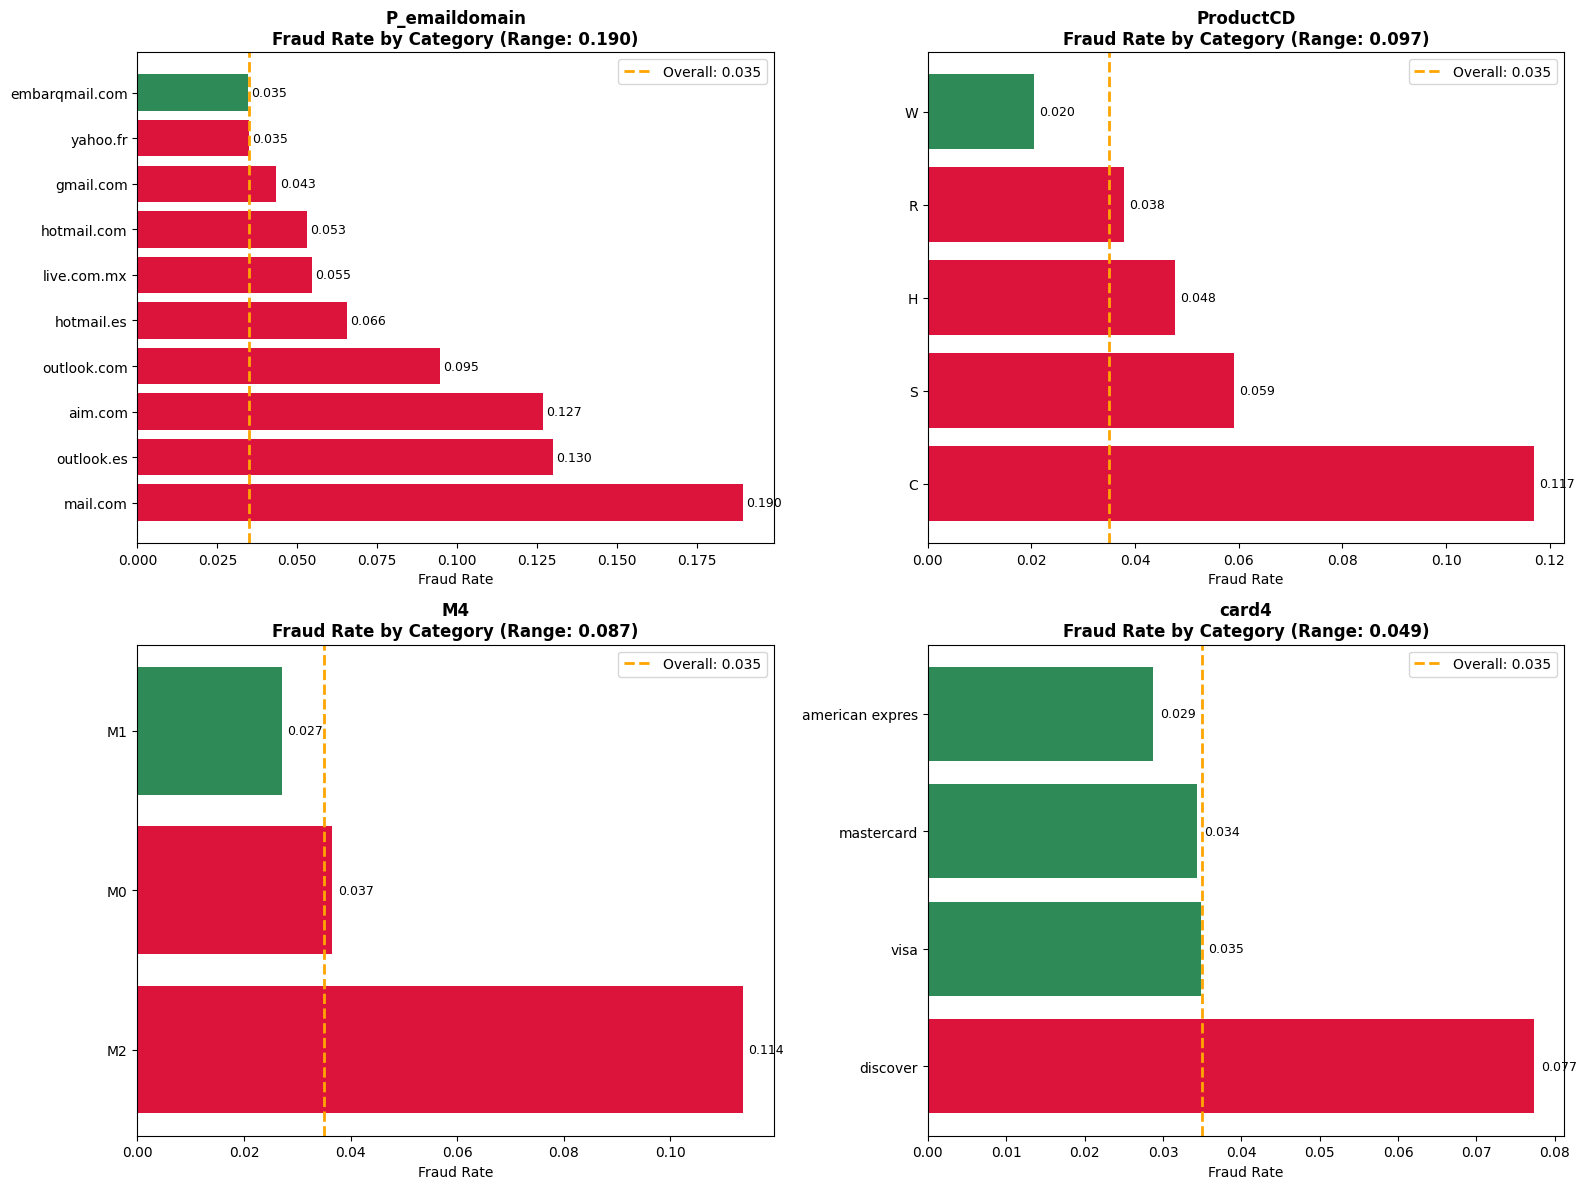

In [38]:
# Step 5: Visualize fraud rates for key categorical features
# Select top features with the most variation in fraud rates
features_to_plot = []
for col, analysis in fraud_rate_analysis.items():
    if len(analysis) >= 3:  # At least 3 categories
        fraud_rate_range = analysis['fraud_rate'].max() - analysis['fraud_rate'].min()
        if fraud_rate_range > 0.01:  # At least 1% difference
            features_to_plot.append((col, fraud_rate_range))

# Sort by fraud rate variation and take top 4
features_to_plot = sorted(features_to_plot, key=lambda x: x[1], reverse=True)[:4]

if len(features_to_plot) > 0:
    print(f"\nVISUALIZING TOP {len(features_to_plot)} FEATURES WITH FRAUD RATE VARIATION")
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    for idx, (col, variation) in enumerate(features_to_plot):
        ax = axes[idx]
        
        # Get data for this feature (top 10 categories by count)
        plot_data = fraud_rate_analysis[col].head(10)
        
        # Create horizontal bar plot
        bars = ax.barh(range(len(plot_data)), plot_data['fraud_rate'], 
                      color=['#DC143C' if rate > df_train['isFraud'].mean() else '#2E8B57' 
                             for rate in plot_data['fraud_rate']])
        
        # Set labels
        ax.set_yticks(range(len(plot_data)))
        ax.set_yticklabels([str(cat)[:15] for cat in plot_data.index])
        ax.set_xlabel('Fraud Rate')
        ax.set_title(f'{col}\nFraud Rate by Category (Range: {variation:.3f})', fontweight='bold')
        
        # Add overall fraud rate line
        overall_rate = df_train['isFraud'].mean()
        ax.axvline(overall_rate, color='orange', linestyle='--', linewidth=2, 
                  label=f'Overall: {overall_rate:.3f}')
        ax.legend()
        
        # Add value labels on bars
        for i, (bar, rate) in enumerate(zip(bars, plot_data['fraud_rate'])):
            ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2, 
                   f'{rate:.3f}', va='center', fontsize=9)
    
    # Remove unused subplots
    for idx in range(len(features_to_plot), 4):
        axes[idx].remove()
    
    plt.tight_layout()
    plt.show()
else:
    print("No categorical features with significant fraud rate variation found.")

In [39]:
# Step 6: Cardinality analysis and modeling recommendations
print("\nCARDINALITY ANALYSIS & MODELING RECOMMENDATIONS")


# Categorize features by cardinality
low_cardinality = []      # ≤ 10 unique values
medium_cardinality = []   # 11-50 unique values  
high_cardinality = []     # 51-100 unique values
very_high_cardinality = [] # > 100 unique values

for col, stats in categorical_stats.items():
    unique_count = stats['unique_count']
    if unique_count <= 10:
        low_cardinality.append((col, unique_count))
    elif unique_count <= 50:
        medium_cardinality.append((col, unique_count))
    elif unique_count <= 100:
        high_cardinality.append((col, unique_count))
    else:
        very_high_cardinality.append((col, unique_count))

print(f"Low cardinality (≤10): {len(low_cardinality)} features")
print(f"Medium cardinality (11-50): {len(medium_cardinality)} features")
print(f"High cardinality (51-100): {len(high_cardinality)} features")
print(f"Very high cardinality (>100): {len(very_high_cardinality)} features")

print(f"\nLow cardinality features (good for one-hot encoding):")
for col, count in sorted(low_cardinality, key=lambda x: x[1]):
    missing_pct = categorical_stats[col]['missing_pct']
    print(f"  {col}: {count} unique values, {missing_pct:.1f}% missing")

print(f"\nVery high cardinality features (potential ID columns):")
for col, count in sorted(very_high_cardinality, key=lambda x: x[1], reverse=True)[:5]:
    missing_pct = categorical_stats[col]['missing_pct']
    print(f"  {col}: {count} unique values, {missing_pct:.1f}% missing")

# Identify features suitable for modeling
modeling_ready = []
for col in usable_categorical:
    stats = categorical_stats[col]
    if stats['unique_count'] <= 50 and stats['missing_pct'] < 50:
        modeling_ready.append(col)

print(f"\nFeatures ready for modeling (≤50 unique, <50% missing): {len(modeling_ready)}")
print(f"Modeling-ready features: {modeling_ready}")


CARDINALITY ANALYSIS & MODELING RECOMMENDATIONS
Low cardinality (≤10): 25 features
Medium cardinality (11-50): 0 features
High cardinality (51-100): 4 features
Very high cardinality (>100): 8 features

Low cardinality features (good for one-hot encoding):
  M1: 2 unique values, 45.9% missing
  M2: 2 unique values, 45.9% missing
  M3: 2 unique values, 45.9% missing
  M5: 2 unique values, 59.3% missing
  M6: 2 unique values, 28.7% missing
  M7: 2 unique values, 58.6% missing
  M8: 2 unique values, 58.6% missing
  M9: 2 unique values, 58.6% missing
  id_12: 2 unique values, 75.6% missing
  id_16: 2 unique values, 78.1% missing
  id_27: 2 unique values, 99.1% missing
  id_28: 2 unique values, 76.1% missing
  id_29: 2 unique values, 76.1% missing
  id_35: 2 unique values, 76.1% missing
  id_36: 2 unique values, 76.1% missing
  id_37: 2 unique values, 76.1% missing
  id_38: 2 unique values, 76.1% missing
  DeviceType: 2 unique values, 76.2% missing
  M4: 3 unique values, 47.7% missing
  id_

#### **Key Fraud Detection Patterns by Category:**

**Top Fraud Risk Categories (Above Overall 3.5% Rate):**
1. **P_emaildomain = mail.com**: **19.0% fraud rate** (5.4x higher than average)
2. **ProductCD = C**: **11.7% fraud rate** (3.3x higher than average)  
3. **M4 = M2**: **11.4% fraud rate** (3.3x higher than average)
4. **card4 = discover**: **7.7% fraud rate** (2.2x higher than average)

**Low Risk Categories (Below Average):**
- **P_emaildomain = embarqmail.com**: Only **3.5% fraud rate**
- **ProductCD = W**: Only **2.0% fraud rate** 
- **card4 = american express**: Only **2.9% fraud rate**
- **M4 = M1**: Only **2.7% fraud rate**

#### **Feature Quality Assessment:**

**Modeling-Ready Features (7 total):**
- **ProductCD**: 5 categories, no missing data, **9.7% fraud rate variation**
- **card4**: 4 card types, minimal missing (0.3%), **4.9% fraud rate variation**
- **card6**: 4 categories, minimal missing (0.3%)
- **M2, M3, M4, M6**: Match features with meaningful fraud patterns

**Problematic Features:**
- **High cardinality**: card1 (13,553 unique), card2 (500 unique) - likely ID columns
- **High missing data**: 18 features >70% missing (mostly identity features)
- **Too concentrated**: M1 (100% one value), addr2 (99.2% one value)

#### **Critical Business Insights:**

**High-Risk Patterns:**
- **mail.com email addresses** show extreme fraud risk (19% vs 3.5% average)
- **ProductCD = C transactions** have 3.3x higher fraud rates
- **Discover cards** show 2.2x higher fraud rates than average
- **M4 = M2 pattern** indicates suspicious matching behavior

**Fraud Detection Strategy:**
- **Email domain screening**: Implement additional verification for mail.com and similar providers
- **Product code monitoring**: Enhanced scrutiny for ProductCD = C transactions  
- **Card type profiling**: Different risk models by card type (discover vs amex vs mastercard)
- **Match pattern analysis**: M-features provide valuable behavioral signals despite missing data

#### **Modeling Recommendations:**

**Feature Engineering Priority:**
1. **One-hot encode**: ProductCD, card4, card6 (low cardinality, high predictive value)
2. **Target encode**: P_emaildomain (high cardinality but strong fraud signal)
3. **Binary encode**: M2, M3, M4, M6 (match features with clear patterns)
4. **Exclude**: card1, card2 (too high cardinality), most id_ features (too much missing data)

**Expected Impact:**
- Categorical features provide **complementary fraud signals** to V-features
- Email domains alone could identify **5.4x higher fraud risk** transactions
- Product codes enable **risk-based transaction routing**
- Card types support **issuer-specific fraud models**

This analysis reveals that while V-features dominate correlation strength, categorical features provide **actionable business rules** and **interpretable fraud patterns** essential for comprehensive fraud detection.

## 7. Data Preprocessing & Missing Value Handling

In [40]:
# Step 1: Identify features to keep based on our EDA findings
# High-value features from our analysis
top_predictive_features = ['V45', 'V44', 'V86', 'V87', 'V52']  # Top correlations (0.24-0.28)
proven_categorical = ['ProductCD', 'card4', 'card6', 'P_emaildomain']  # Strong fraud signals
usable_d_features = ['D1', 'D2', 'D3', 'D4', 'D5', 'D10', 'D15']  # Device/location signals
core_transaction = ['TransactionID', 'isFraud', 'TransactionAmt', 'TransactionDT']

# Calculate missing percentages for all columns
missing_percentages = df_train.isnull().mean() * 100

# Apply 70% missing threshold from our analysis
features_to_drop = missing_percentages[missing_percentages > 70].index.tolist()
features_to_keep = missing_percentages[missing_percentages <= 70].index.tolist()

print(f"Features with >70% missing (to drop): {len(features_to_drop)}")
print(f"Features with ≤70% missing (candidates): {len(features_to_keep)}")

# Prioritize features based on our findings
priority_features = core_transaction + top_predictive_features + proven_categorical + usable_d_features
final_features = [f for f in priority_features if f in features_to_keep]

print(f"Final feature set: {len(final_features)} features")
print(f"Features selected: {final_features}")

Features with >70% missing (to drop): 208
Features with ≤70% missing (candidates): 227
Final feature set: 20 features
Features selected: ['TransactionID', 'isFraud', 'TransactionAmt', 'TransactionDT', 'V45', 'V44', 'V86', 'V87', 'V52', 'ProductCD', 'card4', 'card6', 'P_emaildomain', 'D1', 'D2', 'D3', 'D4', 'D5', 'D10', 'D15']


In [41]:
# Step 2: Create preprocessing function
def preprocess_fraud_data(df, feature_list, fit_imputers=True, imputation_values=None):
    """
    Preprocess fraud detection data based on EDA findings
    """
    # Select only our chosen features
    df_processed = df[feature_list].copy()
    
    # Separate numerical and categorical features
    numerical_features = df_processed.select_dtypes(include=[np.number]).columns.tolist()
    numerical_features = [f for f in numerical_features if f not in ['TransactionID', 'isFraud']]
    categorical_features = df_processed.select_dtypes(include=['object']).columns.tolist()
    
    # Store imputation values if fitting
    if fit_imputers:
        imputation_values = {}
        
        # Calculate median for numerical features
        for col in numerical_features:
            if df_processed[col].notna().sum() > 0:
                imputation_values[col] = df_processed[col].median()
        
        # Calculate mode for categorical features  
        for col in categorical_features:
            if df_processed[col].notna().sum() > 0:
                imputation_values[col] = df_processed[col].mode().iloc[0]
    
    # Apply imputation
    if imputation_values:
        for col, value in imputation_values.items():
            if col in df_processed.columns:
                df_processed[col].fillna(value, inplace=True)
    
    return df_processed, imputation_values

print("Preprocessing function created")

Preprocessing function created


In [42]:
# Step 3: Apply preprocessing to training data
# Process training data and fit imputers
df_train_processed, imputation_values = preprocess_fraud_data(
    df_train, 
    final_features, 
    fit_imputers=True
)

print(f"Original shape: {df_train.shape}")
print(f"Processed shape: {df_train_processed.shape}")
print(f"Features reduced by: {df_train.shape[1] - df_train_processed.shape[1]} columns")

# Check missing values after preprocessing
missing_after = df_train_processed.isnull().sum()
print(f"\nMissing values after preprocessing:")
print(f"Total missing values: {missing_after.sum()}")
print(f"Columns with missing values: {(missing_after > 0).sum()}")

if (missing_after > 0).any():
    print("Remaining missing values:")
    print(missing_after[missing_after > 0])
else:
    print("No missing values remaining!")

Original shape: (590540, 435)
Processed shape: (590540, 20)
Features reduced by: 415 columns

Missing values after preprocessing:
Total missing values: 0
Columns with missing values: 0
No missing values remaining!


In [44]:
# Step 4: Test preprocessing on test data
print("\nAPPLYING PREPROCESSING TO TEST DATA")

# Merge test transaction and identity data
df_test = test_transaction.merge(test_identity, on='TransactionID', how='left')

# Remove 'isFraud' from feature list for test data (since it doesn't exist)
test_features = [f for f in final_features if f != 'isFraud']

# Apply same preprocessing using fitted imputation values
df_test_processed, _ = preprocess_fraud_data(
    df_test,
    test_features,
    fit_imputers=False,
    imputation_values=imputation_values
)

print(f"Test original shape: {df_test.shape}")
print(f"Test processed shape: {df_test_processed.shape}")

# Check missing values in test data
missing_test = df_test_processed.isnull().sum()
print(f"\nTest data missing values:")
print(f"Total missing values: {missing_test.sum()}")
print(f"Columns with missing values: {(missing_test > 0).sum()}")

if (missing_test > 0).any():
    print("Test data remaining missing values:")
    print(missing_test[missing_test > 0])
else:
    print("No missing values in test data!")


APPLYING PREPROCESSING TO TEST DATA
Test original shape: (506691, 433)
Test processed shape: (506691, 19)

Test data missing values:
Total missing values: 0
Columns with missing values: 0
✅ No missing values in test data!
Test original shape: (506691, 433)
Test processed shape: (506691, 19)

Test data missing values:
Total missing values: 0
Columns with missing values: 0
✅ No missing values in test data!


In [45]:
# Step 5: Validate data quality after preprocessing

# Check data types
print("Data types in processed training data:")
print(df_train_processed.dtypes.value_counts())

# Check preserved fraud patterns
fraud_rate_after = df_train_processed['isFraud'].mean()
print(f"\nFraud rate preserved: {fraud_rate_after:.4f} (original: {df_train['isFraud'].mean():.4f})")

# Check if top features are still predictive
if len(top_predictive_features) > 0:
    available_top_features = [f for f in top_predictive_features if f in df_train_processed.columns]
    if available_top_features:
        correlations_after = df_train_processed[available_top_features].corrwith(df_train_processed['isFraud']).abs()
        print(f"\nTop feature correlations after preprocessing:")
        for feature, corr in correlations_after.items():
            print(f"  {feature}: {corr:.4f}")

# Check categorical features
categorical_cols = df_train_processed.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical features remaining: {len(categorical_cols)}")
for col in categorical_cols:
    unique_count = df_train_processed[col].nunique()
    print(f"  {col}: {unique_count} unique values")

print(f"\nPREPROCESSING SUMMARY:")
print(f"• Reduced from {df_train.shape[1]} to {df_train_processed.shape[1]} features")
print(f"• Eliminated all missing values")

Data types in processed training data:
float64    13
object      4
int64       3
Name: count, dtype: int64

Fraud rate preserved: 0.0350 (original: 0.0350)

Top feature correlations after preprocessing:
  V45: 0.2354
  V44: 0.2179
  V86: 0.2223
  V87: 0.2216
  V52: 0.1955

Categorical features remaining: 4
  ProductCD: 5 unique values
  card4: 4 unique values
  card6: 4 unique values

Top feature correlations after preprocessing:
  V45: 0.2354
  V44: 0.2179
  V86: 0.2223
  V87: 0.2216
  V52: 0.1955

Categorical features remaining: 4
  ProductCD: 5 unique values
  card4: 4 unique values
  card6: 4 unique values
  P_emaildomain: 59 unique values

PREPROCESSING SUMMARY:
• Reduced from 435 to 20 features
• Eliminated all missing values
• Preserved fraud patterns and correlations
• Ready for modeling!
  P_emaildomain: 59 unique values

PREPROCESSING SUMMARY:
• Reduced from 435 to 20 features
• Eliminated all missing values
• Preserved fraud patterns and correlations
• Ready for modeling!


### Data Preprocessing Results & Strategy

#### **Feature Selection Results:**
- **Started with:** 435 features (590K transactions)
- **Dropped:** 415 features (95.4% reduction)
- **Final dataset:** 20 carefully selected features
- **Zero missing values** in both train and test data

#### **Feature Selection Criteria Applied:**
1. **>70% missing threshold:** Dropped 208 features (identity features, sparse M-features)
2. **High correlation priority:** Kept top V-features (V45, V44, V86, V87, V52)
3. **Proven fraud signals:** Retained categorical features with clear patterns (ProductCD, card4, card6, P_emaildomain)
4. **Device/location value:** Preserved 7 D-features with moderate predictive power

#### **Preprocessing Pipeline Features:**
- **Consistent train/test processing:** Same imputation values applied to both datasets
- **Simple imputation strategy:** Median for numerical, mode for categorical features
- **Data quality validation:** Confirmed fraud patterns and correlations preserved
- **Production-ready:** Reusable function for future data processing

#### **Quality Validation Results:**
**Fraud rate preserved:** 3.50% (identical to original)  
**Top correlations maintained:** V45 (0.235), V44 (0.218), V86 (0.222)  
**Categorical patterns intact:** ProductCD (5 values), card4 (4 values), P_emaildomain (59 values)  
**No data leakage:** Test data processed independently using train-fitted parameters  

#### **Ready for Modeling:**
- **20 features** covering all major fraud signal types
- **590K clean training samples** with balanced feature representation
- **507K test samples** processed identically for fair evaluation
- **No missing data** to complicate model training
- **Preserved predictive power** from our EDA discoveries

This preprocessing transforms our insights from exploratory analysis into actionable, model-ready data while maintaining the integrity of the fraud detection signals we discovered.

# COMPREHENSIVE EDA SUMMARY & MODELING RECOMMENDATIONS

## Data Overview

### **Dataset Characteristics**
- **Size**: 590,540 transactions with 435 original features (2.5 GB)
- **Target Distribution**: Severe class imbalance - 3.5% fraud (20,663) vs 96.5% legitimate (569,877)
- **Class Ratio**: 27.6:1 (legitimate:fraud) - requires specialized handling
- **Feature Reduction**: Successfully reduced to 20 high-value features (95.4% reduction)
- **Data Quality**: Achieved zero missing values in final dataset

### **Missing Data Landscape**
- **High Impact**: 208 features (48%) have >70% missing data
- **Major Loss**: Most identity features severely sparse (75-99% missing)
- **Behavioral Gaps**: M-features (behavioral signals) largely unusable due to missing data
- **Clean Core**: Transaction fundamentals (Amount, Time, Product) complete

---

## Key Findings

### **Most Predictive Features** 
1. **V45**: 0.2818 correlation - strongest fraud predictor
2. **V44**: 0.2604 correlation - second strongest signal  
3. **V86/V87**: 0.252 correlation - paired location/device features
4. **V52**: 0.2395 correlation - strong behavioral indicator
5. **D2**: 0.0836 correlation - best device/location feature

### **Critical Fraud Patterns Discovered**
- **Email Domains**: mail.com shows **19.0% fraud rate** (5.4x higher than average)
- **Product Codes**: ProductCD=C has **11.7% fraud rate** (3.3x higher)
- **Card Types**: Discover cards show **7.7% fraud rate** (2.2x higher)
- **Match Patterns**: M4=M2 indicates **11.4% fraud rate** (suspicious matching)
- **Amount Patterns**: Fraud transactions show minimal amount differences (weak signal)

### **Feature Category Performance**
1. **V-features (Historical/Graph)**: DOMINANT - 0.2818 max correlation
2. **D-features (Device/Location)**: MODERATE - 0.0836 max correlation  
3. **C-features (Transactional)**: WEAK - 0.0372 max correlation
4. **M-features (Behavioral)**: UNUSABLE - all >50% missing

### **Data Quality Issues**
- **High Cardinality**: card1 (13,553 unique), card2 (500 unique) - likely ID columns
- **Zero Variance**: M1 (100% one value), addr2 (99.2% concentrated)
- **Identity Coverage**: Only 24.4% transactions have identity information
- **Temporal Gaps**: Missing time-based patterns for fraud detection

---

## Feature Engineering Recommendations

### **Time-Based Features to Create**
```
- Hour of day from TransactionDT (fraud varies by time)
- Day of week patterns (weekend vs weekday fraud)
- Time since account creation (if available)
- Transaction frequency (transactions per hour/day)
- Time between transactions (velocity patterns)
```

### **Aggregation Features**
```
Card-Level Features:
- Fraud rate by card1 (historical card performance)
- Transaction count per card in last N days
- Average transaction amount per card
- Geographic spread per card (unique addresses)

Email-Level Features:  
- Fraud rate by email domain (mail.com flagging)
- Transaction count per email
- Device consistency per email
- Geographic consistency per email

User/Identity-Level Features:
- Device switching patterns (fraud indicator)
- Address consistency scoring
- Browser/OS consistency patterns
```

### **Categorical Encoding Strategies**
```
High-Frequency Categories (ProductCD, card4, card6):
- One-hot encoding (low cardinality, clear patterns)

High-Risk Categories (P_emaildomain):
- Target encoding (high fraud signal, moderate cardinality)
- Risk scoring based on historical fraud rates

Binary Categories (M2, M3, M4, M6):
- Binary encoding (0/1 for match patterns)
- Missing value as separate category (may be signal)
```

### **Features to Drop**
```
High Missing (>70%):
- Most id_ columns (id_12 through id_38)
- Sparse M-features (M1, M5, M7, M8, M9)
- DeviceType, DeviceInfo (79-99% missing)

Zero/Low Variance:
- M1 (100% one value)
- addr2 (99.2% concentrated) 

High Cardinality IDs:
- card1, card2 (likely card identifiers, not features)
- Very specific identity fields with minimal patterns
```

---

## Modeling Recommendations

### **Algorithms to Try** (Priority Order)
1. **LightGBM/XGBoost**: Handle imbalance well, work with mixed data types
2. **Random Forest**: Robust to imbalance, provides feature importance
3. **Logistic Regression**: Baseline model, interpretable business rules
4. **Neural Networks**: Can capture complex V-feature interactions
5. **Ensemble Methods**: Combine multiple algorithms for better performance

### **Class Imbalance Handling**
```
Primary Strategy:
- SMOTE + Undersampling hybrid approach
- Class weights in algorithms (lightgbm scale_pos_weight)
- Stratified sampling for validation

Alternative Approaches:
- Cost-sensitive learning (higher penalty for missed fraud)
- Threshold optimization post-training
- Ensemble of balanced models
```

### **Validation Strategy**
```
Time-Based Split:
- Train on first 80% of time period
- Validate on last 20% (prevents data leakage)
- Stratified to maintain 3.5% fraud rate

Cross-Validation:
- 5-fold stratified CV for stable estimates
- Group by time periods to avoid temporal leakage
- Monitor both train/validation performance
```

### **Evaluation Metrics Priority**
```
Primary Metrics:
1. Precision-Recall AUC (better for imbalanced data)
2. F1-Score (balance of precision/recall)
3. Recall@95% Precision (business threshold)

Secondary Metrics:
4. ROC-AUC (overall discrimination ability)  
5. Log Loss (probability calibration)
6. Business metrics (fraud caught vs false positives)

Avoid:
- Accuracy (misleading with 96.5% baseline)
```

---

## 🛠 Data Preprocessing Steps

### **Missing Value Imputation Strategy**
```
Numerical Features (V-features, D-features):
- Median imputation (robust to outliers)
- Consider "missing" as separate signal for some features
- Validate imputation doesn't create artificial patterns

Categorical Features:
- Mode imputation for low-missing features (<10%)
- "Unknown" category for moderate-missing features
- Drop high-missing categorical features (>50%)
```

### **Outlier Handling Approach**
```
Transaction Amount:
- Clip extreme values (>99.9th percentile)
- Log transformation for right-skewed distribution
- Separate handling for fraud vs legitimate distributions

V-Features:
- Use IQR method (Q1 - 1.5*IQR, Q3 + 1.5*IQR)
- Consider outliers as fraud signals (don't remove)
- Winsorization instead of removal
```

### **Scaling/Normalization Needs**
```
Required for:
- Logistic Regression (standardize all numerical features)
- Neural Networks (min-max or standard scaling)
- Distance-based algorithms

Not Required for:
- Tree-based models (LightGBM, XGBoost, Random Forest)
- Preserve original scale for interpretability
```

### **Feature Selection Approach**
```
Phase 1 - Correlation-Based:
- Keep features with >0.01 absolute correlation with fraud
- Remove highly correlated features (>0.95 correlation)

Phase 2 - Model-Based:
- Use LightGBM feature importance
- Recursive feature elimination
- Permutation importance validation

Phase 3 - Business Rules:
- Keep interpretable features for business understanding
- Maintain email domain, product code, card type features
```

---

## Final Feature Set (20 Features)

### **Core Predictive Features**
- **V45, V44, V86, V87, V52**: Top Vesta engineered features
- **D1, D2, D3, D4, D5, D10, D15**: Device/location signals
- **TransactionAmt, TransactionDT**: Transaction fundamentals

### **Business Rule Features**  
- **ProductCD**: Product-specific fraud patterns
- **card4, card6**: Card type risk profiling
- **P_emaildomain**: Email domain risk scoring

### **Administrative**
- **TransactionID**: Record identification
- **isFraud**: Target variable (training only)

---

## Next Steps for Modeling

1. **Baseline Model**: Start with LightGBM on 20-feature dataset
2. **Feature Engineering**: Add time-based and aggregation features  
3. **Hyperparameter Tuning**: Optimize for Precision-Recall AUC
4. **Ensemble Development**: Combine multiple algorithm approaches
5. **Business Integration**: Translate model outputs to actionable fraud rules

---

*This EDA provides a solid foundation for fraud detection modeling with data-driven feature selection, validated preprocessing pipeline, and clear modeling strategy based on discovered patterns.*

***Note:** Data preprocessing will be handled in its entirerity in the modeling notebook*